# Simulation-Based Inference for Pulsar Timing Red Noise

## A Physicist's Guide to Amortized Neural Posterior Estimation

---

This tutorial walks through a complete **simulation-based inference (SBI)** pipeline designed for inferring red-noise parameters from pulsar timing data. By the end, you will:

1. Understand *why* SBI is useful when likelihoods are expensive or intractable
2. See exactly how the toy forward model (simulator) works
3. Generate synthetic pulsar timing data and compute exact posteriors
4. Load a trained neural posterior estimator and obtain posteriors **instantly** — demonstrating the power of *amortized* inference

### What is SBI?

Traditional Bayesian inference requires evaluating the likelihood $p(\mathbf{d} \mid \boldsymbol{\theta})$ many thousands of times (e.g. via MCMC). For complex physical models this becomes prohibitively expensive.

**Simulation-based inference** sidesteps this by training a neural network on simulated $(\boldsymbol{\theta}, \mathbf{d})$ pairs:

$$
\boldsymbol{\theta} \sim p(\boldsymbol{\theta}), \quad \mathbf{d} \sim p(\mathbf{d} \mid \boldsymbol{\theta})
$$

The network learns a *conditional density estimator* $q_\phi(\boldsymbol{\theta} \mid \mathbf{d})$ that approximates the true posterior. Once trained, inference on **any new observation** requires only a single forward pass — no MCMC, no likelihood evaluations. This is called **amortized inference**.

### The Physical Setup

We consider a single pulsar observed over several years with irregular cadence (gaps between observing seasons, variable cadence, missing epochs). The pulsar's timing residuals contain:

- **Red noise**: a stochastic process with a power-law spectrum $S(f) \propto A^2 \left(\frac{f}{f_{\rm ref}}\right)^{-\gamma}$
- **White noise**: Gaussian measurement noise with known uncertainties $\sigma_i$

We want to infer two parameters:

| Parameter | Symbol | Prior Range | Physical Meaning |
|-----------|--------|-------------|------------------|
| Red noise amplitude | $\log_{10} A_{\rm red}$ | $[-2.5, -0.5]$ | Overall strength of low-frequency noise |
| Spectral index | $\gamma_{\rm red}$ | $[0.5, 6.5]$ | Steepness of the power spectrum |

In [1]:
import sys, os

# Ensure the project root is on the path
PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

# Fix seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"NumPy {np.__version__}, PyTorch {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

NumPy 2.4.3, PyTorch 2.6.0+cu124
Device: cuda


---
## 1. The Forward Model: From Parameters to Data

### 1.1 Observing Schedule

Real pulsar timing observations are **irregular**: telescopes observe during seasonal windows (~8 months/year), with variable cadence and occasional missing seasons. Our synthetic schedule generator mimics this:

- Random baseline length: 5–15 years
- Seasonal windows with ~20% chance of missing each year
- Variable cadence (2–6 week mean gaps)
- Heteroskedastic uncertainties $\sigma_i$ (log-uniform in $[10^{-2}, 10^0]$)
- Multiple observing frequencies (820, 1400, 2300 MHz) and backend instruments

Let's generate a few example schedules and see how they look.

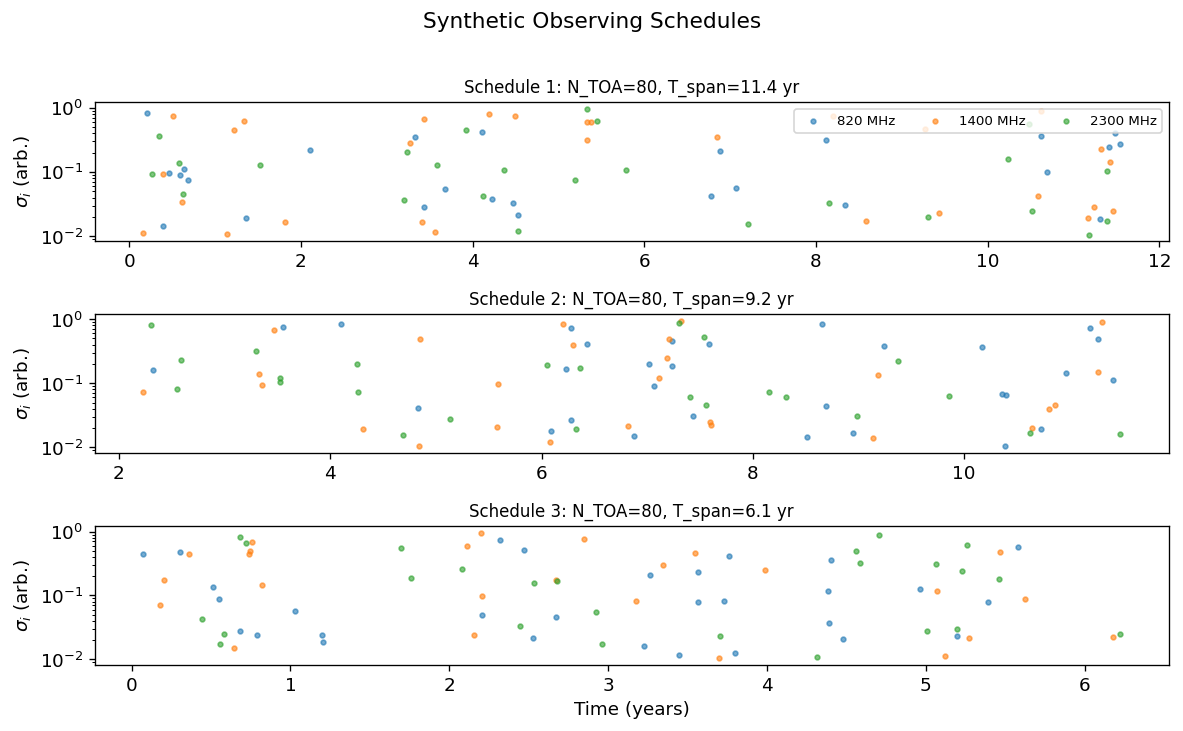

Notice the seasonal gaps, variable cadence, and heteroskedastic σ.


In [2]:
from src.schedules import generate_schedule

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=False)

for i, ax in enumerate(axes):
    rng = np.random.default_rng(SEED + i)
    sched = generate_schedule(rng)
    
    # Color by observing frequency
    colors = {820.0: 'C0', 1400.0: 'C1', 2300.0: 'C2'}
    for freq_val in np.unique(sched.freq_mhz):
        mask = sched.freq_mhz == freq_val
        ax.scatter(sched.t[mask], sched.sigma[mask], s=8, alpha=0.6,
                   c=colors.get(freq_val, 'gray'), label=f'{freq_val:.0f} MHz')
    
    ax.set_ylabel('$\\sigma_i$ (arb.)')
    ax.set_yscale('log')
    ax.set_title(f'Schedule {i+1}: N_TOA={sched.n_toa}, T_span={sched.tspan:.1f} yr', fontsize=10)
    if i == 0:
        ax.legend(fontsize=8, ncol=3, loc='upper right')

axes[-1].set_xlabel('Time (years)')
fig.suptitle('Synthetic Observing Schedules', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

print(f"Notice the seasonal gaps, variable cadence, and heteroskedastic σ.")

### 1.2 The Fourier-Basis Red Noise Model

The red-noise signal is modelled via a **Fourier design matrix**. Given $N$ observation times $\{t_i\}$ and $K$ frequency modes:

$$
\mathbf{F} = \begin{pmatrix} \cos(2\pi f_1 t_1) & \sin(2\pi f_1 t_1) & \cdots & \cos(2\pi f_K t_1) & \sin(2\pi f_K t_1) \\ \vdots & & & & \vdots \\ \cos(2\pi f_1 t_N) & \sin(2\pi f_1 t_N) & \cdots & \cos(2\pi f_K t_N) & \sin(2\pi f_K t_N) \end{pmatrix}
$$

where $f_k = k / T_{\rm span}$ for $k = 1, \ldots, K$.

The **per-mode variance** follows a power law controlled by our two parameters:

$$
\rho_k = A^2 \left(\frac{f_k}{f_{\rm ref}}\right)^{-\gamma} \Delta f, \qquad A = 10^{\log_{10} A_{\rm red}}, \quad \Delta f = \frac{1}{T_{\rm span}}
$$

The full data covariance is:

$$
\mathbf{C}(\boldsymbol{\theta}) = \text{diag}(\sigma_i^2) + \mathbf{F} \, \boldsymbol{\Phi}(\boldsymbol{\theta}) \, \mathbf{F}^\top
$$

where $\boldsymbol{\Phi} = \text{diag}(\rho_1, \rho_1, \rho_2, \rho_2, \ldots)$. The Fourier coefficients $\mathbf{a}$ are drawn as:

$$
a_j \sim \mathcal{N}(0, \Phi_{jj})
$$

and the observed residuals are:

$$
r_i = (\mathbf{F} \mathbf{a})_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma_i^2)
$$

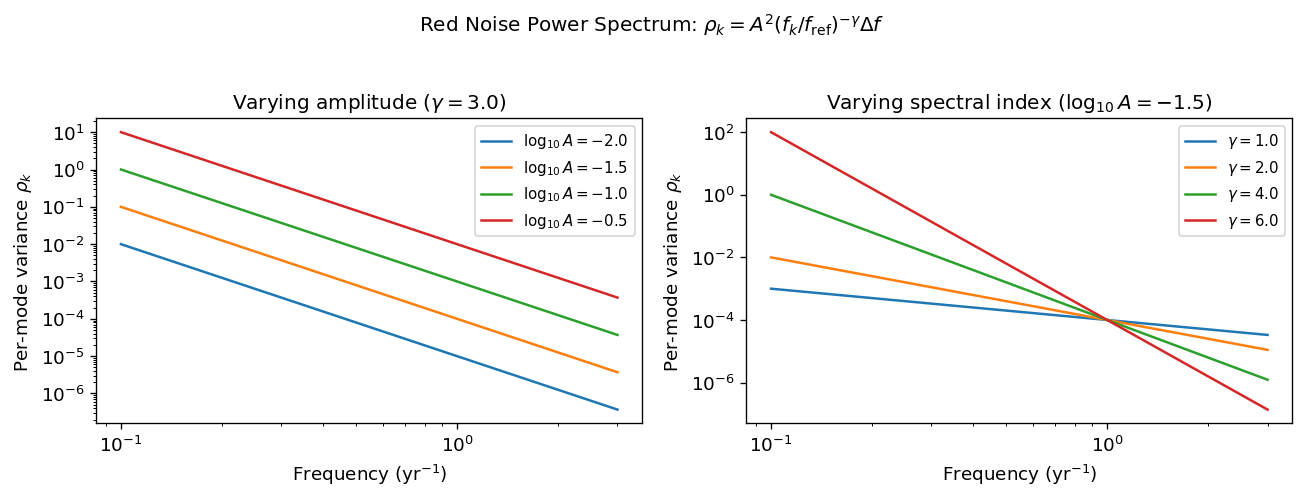

In [3]:
from src.simulator import simulate_pulsar, build_fourier_design_matrix, power_law_spectrum

# Let's visualize the power spectrum for different parameter combinations
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

tspan = 10.0  # years
n_modes = 30
freqs = np.arange(1, n_modes + 1) / tspan

# Left: vary amplitude
for log10_A in [-2.0, -1.5, -1.0, -0.5]:
    rho = power_law_spectrum(n_modes, tspan, log10_A, gamma=3.0)
    axes[0].loglog(freqs, rho, label=f'$\\log_{{10}} A = {log10_A}$')
axes[0].set_xlabel('Frequency (yr$^{-1}$)')
axes[0].set_ylabel('Per-mode variance $\\rho_k$')
axes[0].set_title('Varying amplitude ($\\gamma = 3.0$)')
axes[0].legend(fontsize=9)

# Right: vary spectral index
for gamma in [1.0, 2.0, 4.0, 6.0]:
    rho = power_law_spectrum(n_modes, tspan, -1.5, gamma)
    axes[1].loglog(freqs, rho, label=f'$\\gamma = {gamma}$')
axes[1].set_xlabel('Frequency (yr$^{-1}$)')
axes[1].set_ylabel('Per-mode variance $\\rho_k$')
axes[1].set_title('Varying spectral index ($\\log_{10} A = -1.5$)')
axes[1].legend(fontsize=9)

fig.suptitle('Red Noise Power Spectrum: $\\rho_k = A^2 (f_k / f_{\\rm ref})^{-\\gamma} \\Delta f$',
             fontsize=12, y=1.03)
fig.tight_layout()
plt.show()

### 1.3 Simulating a Pulsar

Let's simulate several pulsars with different parameter values to see how the signal changes across parameter space. The key degeneracy: **both increasing amplitude and steepening spectral index produce more low-frequency power**, making them partially correlated in the posterior.

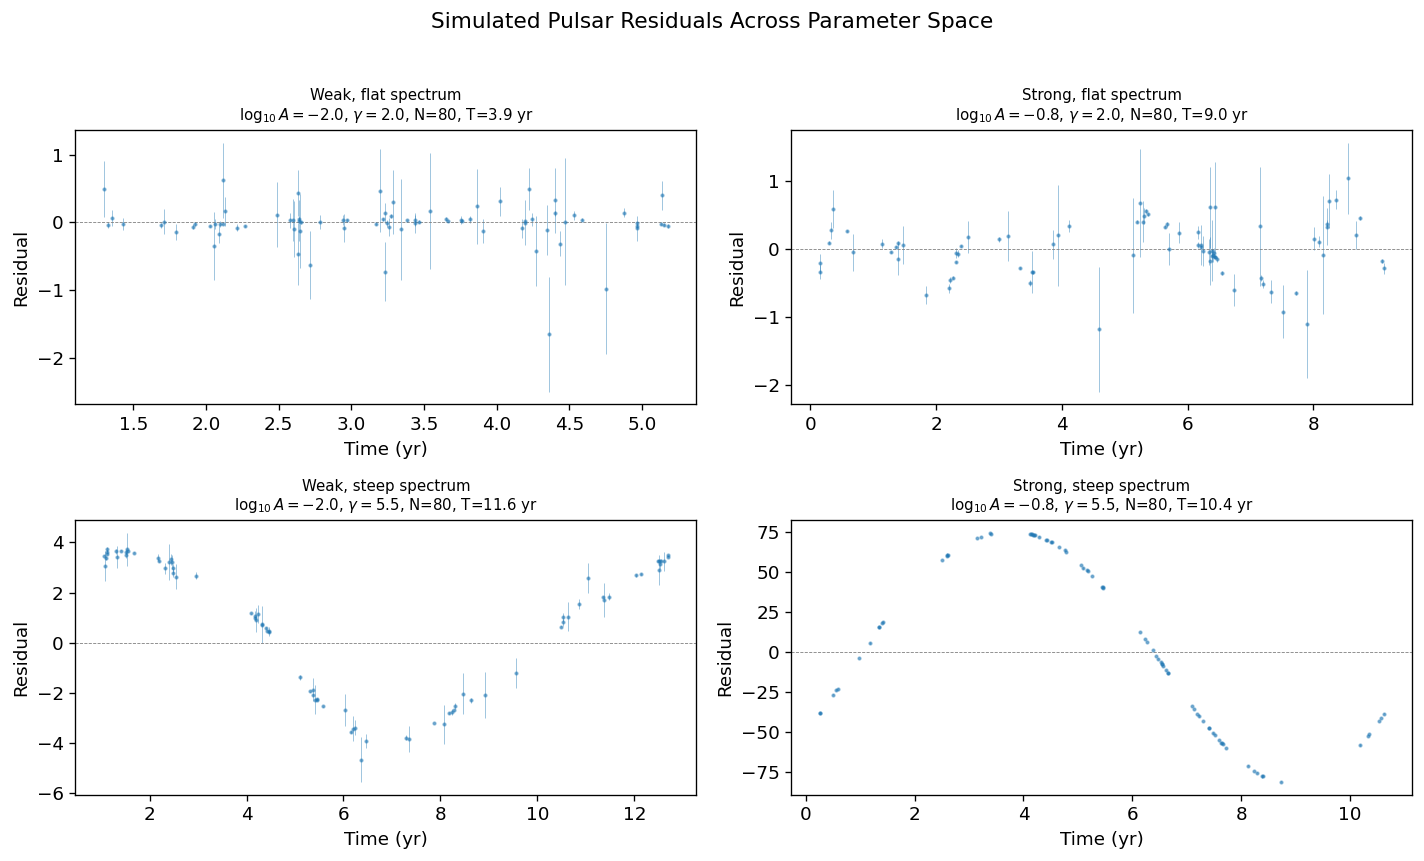

In [4]:
from src.priors import UniformPrior

prior_bounds = {'log10_A_red': [-2.5, -0.5], 'gamma_red': [0.5, 6.5]}
prior = UniformPrior(prior_bounds)

# Simulate pulsars at different corners of parameter space
test_params = [
    (np.array([-2.0, 2.0]), 'Weak, flat spectrum'),
    (np.array([-0.8, 2.0]), 'Strong, flat spectrum'),
    (np.array([-2.0, 5.5]), 'Weak, steep spectrum'),
    (np.array([-0.8, 5.5]), 'Strong, steep spectrum'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for i, (theta, label) in enumerate(test_params):
    rng = np.random.default_rng(SEED + 100 + i)
    sched = generate_schedule(rng)
    sim = simulate_pulsar(theta, sched, n_modes=30, rng=rng)
    
    ax = axes[i]
    ax.errorbar(sim.t, sim.residuals, yerr=sim.sigma, fmt='.', ms=3, alpha=0.5,
                elinewidth=0.5, capsize=0)
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.set_title(f'{label}\n$\\log_{{10}} A={theta[0]:.1f}$, $\\gamma={theta[1]:.1f}$, '
                 f'N={len(sim.t)}, T={sim.tspan:.1f} yr', fontsize=9)
    ax.set_xlabel('Time (yr)')
    ax.set_ylabel('Residual')

fig.suptitle('Simulated Pulsar Residuals Across Parameter Space', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

#### Why do some residuals look sinusoidal?

You may notice that the **steep-spectrum** cases ($\gamma = 5.5$) look strikingly sinusoidal, while the **flat-spectrum** cases ($\gamma = 2.0$) look more like band-limited noise. This is not a bug — it's a direct consequence of the power-law spectrum.

The per-mode variance ratio between the fundamental ($k=1$) and $k$-th harmonic is:

$$
\frac{\rho_1}{\rho_k} = k^{\gamma}
$$

For $\gamma = 5.5$, the first mode has $2^{5.5} \approx 45\times$ more variance than the second mode, and $30^{5.5} \approx 7 \times 10^7$ times more than the 30th mode. The random realization is overwhelmingly dominated by a single $\cos(2\pi t/T_{\rm span}) + \sin(2\pi t/T_{\rm span})$ term — i.e., a sinusoid at the fundamental frequency.

For $\gamma = 2.0$, the ratio is only $2^2 = 4\times$ per octave, so multiple modes contribute and the result looks more like broadband correlated noise.

This is exactly what happens in real pulsar timing: **steep red noise spectra are dominated by their lowest Fourier modes**, and this is well known in the PTA literature. The cell below quantifies this for the parameters used above.

In [ ]:
# Quantify the mode dominance for different spectral indices
tspan_demo = 10.0
n_modes_demo = 30

print("Fraction of total red-noise variance in the fundamental (k=1) mode:")
print("=" * 60)
for gamma_demo in [2.0, 3.5, 5.5]:
    rho = power_law_spectrum(n_modes_demo, tspan_demo, log10_A=-1.5, gamma=gamma_demo)
    frac_k1 = rho[0] / rho.sum()
    ratio_k1_k2 = rho[0] / rho[1]
    print(f"  γ = {gamma_demo:.1f}:  ρ₁/Σρ = {frac_k1:.1%},  ρ₁/ρ₂ = {ratio_k1_k2:.1f}×")

print("\nSteep spectra → fundamental mode dominates → sinusoidal appearance.")
print("Flat spectra  → many modes contribute → broadband correlated noise.")

---
## 2. The Exact Posterior (Our Ground Truth)

Because the signal model is **linear in Fourier coefficients** and the noise is **Gaussian**, the likelihood is analytic:

$$
p(\mathbf{r} \mid \boldsymbol{\theta}) = \mathcal{N}(\mathbf{r}; \, \mathbf{0}, \, \mathbf{C}(\boldsymbol{\theta}))
$$

$$
\log p(\mathbf{r} \mid \boldsymbol{\theta}) = -\frac{1}{2} \left[ N \ln(2\pi) + \ln |\mathbf{C}| + \mathbf{r}^\top \mathbf{C}^{-1} \mathbf{r} \right]
$$

With a **uniform prior**, the posterior is proportional to the likelihood. We can evaluate it on a grid and normalize — giving us **exact ground truth** to validate the neural network against.

This is what makes this problem an ideal testbed: we have a gold standard to measure how well the SBI network performs.

In [5]:
from src.exact_posterior import exact_posterior_grid

# Generate one pulsar and compute exact posterior
rng = np.random.default_rng(2024)
theta_true = prior.sample(1, rng=rng).squeeze(0).numpy()
sched = generate_schedule(rng)
sim = simulate_pulsar(theta_true, sched, n_modes=30, rng=rng)

print(f"True parameters: log10_A = {theta_true[0]:.3f}, gamma = {theta_true[1]:.3f}")
print(f"Schedule: N_TOA = {len(sim.t)}, T_span = {sim.tspan:.2f} yr")

# Compute exact posterior on a grid (this is the expensive step!)
exact = exact_posterior_grid(
    sim.residuals, sim.sigma, sim.F, sim.tspan, sim.n_modes,
    prior_bounds, n_grid=80, jitter=1e-6,
)

print(f"\nExact MAP estimate: log10_A = {exact['map_theta'][0]:.3f}, gamma = {exact['map_theta'][1]:.3f}")
print(f"Exact posterior mean: log10_A = {exact['posterior_mean'][0]:.3f}, gamma = {exact['posterior_mean'][1]:.3f}")

True parameters: log10_A = -1.148, gamma = 1.786
Schedule: N_TOA = 80, T_span = 7.86 yr

Exact MAP estimate: log10_A = -1.133, gamma = 2.475
Exact posterior mean: log10_A = -1.120, gamma = 2.534


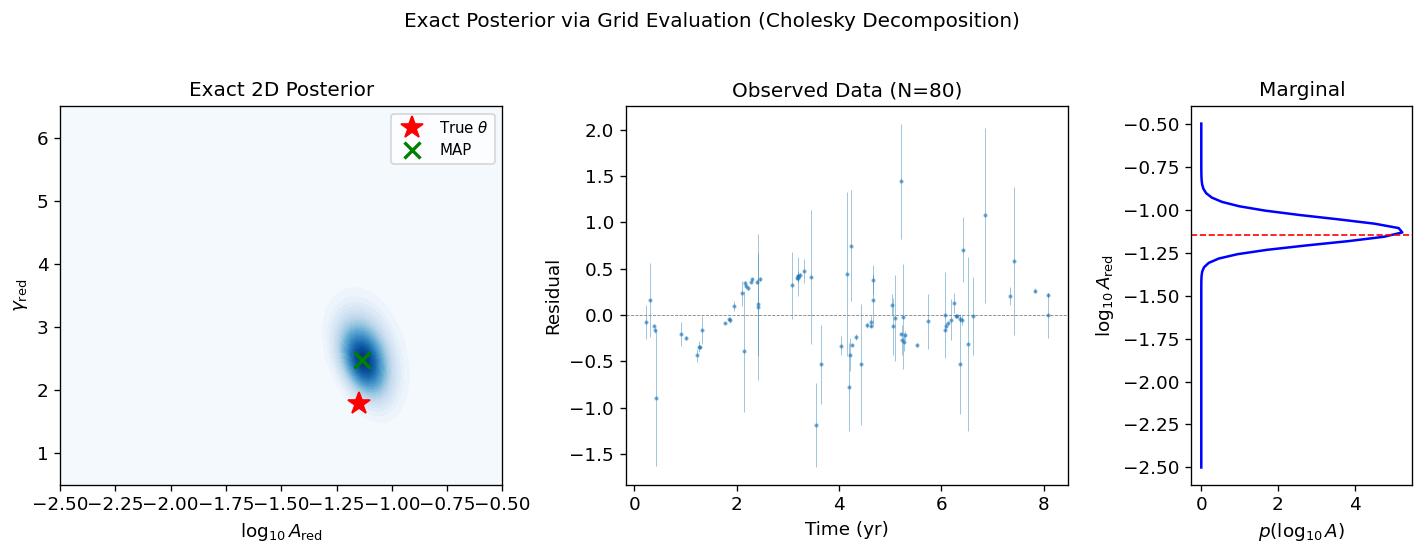


Computing the exact posterior required evaluating the likelihood on a 80×80 = 6400 grid.
Each evaluation involves an O(N³) Cholesky decomposition with N=80 TOAs.
This scales poorly — imagine doing it for 100+ pulsars with thousands of TOAs!


In [6]:
# Plot the exact posterior
fig = plt.figure(figsize=(12, 4.5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.5])

# 2D posterior
ax0 = fig.add_subplot(gs[0])
AG, GG = np.meshgrid(exact['log10_A_grid'], exact['gamma_grid'], indexing='ij')
ax0.contourf(AG, GG, exact['posterior'], levels=30, cmap='Blues')
ax0.plot(theta_true[0], theta_true[1], 'r*', ms=14, label='True $\\theta$')
ax0.plot(exact['map_theta'][0], exact['map_theta'][1], 'gx', ms=10, mew=2, label='MAP')
ax0.set_xlabel('$\\log_{10} A_{\\rm red}$')
ax0.set_ylabel('$\\gamma_{\\rm red}$')
ax0.set_title('Exact 2D Posterior')
ax0.legend(fontsize=9)

# Residuals
ax1 = fig.add_subplot(gs[1])
ax1.errorbar(sim.t, sim.residuals, yerr=sim.sigma, fmt='.', ms=3, alpha=0.5,
             elinewidth=0.5, capsize=0)
ax1.axhline(0, color='gray', ls='--', lw=0.5)
ax1.set_xlabel('Time (yr)')
ax1.set_ylabel('Residual')
ax1.set_title(f'Observed Data (N={len(sim.t)})')

# 1D marginals
ax2 = fig.add_subplot(gs[2])
ax2.plot(exact['marginal_log10_A'], exact['log10_A_grid'], 'b-', lw=1.5)
ax2.axhline(theta_true[0], color='r', ls='--', lw=1)
ax2.set_xlabel('$p(\\log_{10} A)$')
ax2.set_ylabel('$\\log_{10} A_{\\rm red}$')
ax2.set_title('Marginal')

fig.suptitle('Exact Posterior via Grid Evaluation (Cholesky Decomposition)', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

print(f"\nComputing the exact posterior required evaluating the likelihood on a "
      f"{len(exact['log10_A_grid'])}×{len(exact['gamma_grid'])} = "
      f"{len(exact['log10_A_grid'])*len(exact['gamma_grid'])} grid.")
print(f"Each evaluation involves an O(N³) Cholesky decomposition with N={len(sim.t)} TOAs.")
print(f"This scales poorly — imagine doing it for 100+ pulsars with thousands of TOAs!")

---
## 3. The SBI Architecture

Our SBI pipeline has three stages:

### Stage 1: Tokenization

Each TOA (time-of-arrival) is converted into a **token** — a feature vector with 6 continuous features plus a categorical backend ID:

| Feature | Formula | Purpose |
|---------|---------|--------|
| `t_norm` | $(t_i - t_{\min}) / T_{\rm span}$ | Normalized time in [0, 1] |
| `dt_prev` | $(t_i - t_{i-1}) / T_{\rm span}$ | Gap to previous observation |
| `r_over_sig` | $\text{sign}(r_i/\sigma_i) \cdot \log(1 + |r_i/\sigma_i|)$ | Signal-to-noise (log-compressed) |
| `log_sigma` | $\log_{10}(\sigma_i)$ | Noise level |
| `r_raw` | $r_i$ | Raw residual |
| `freq_norm` | $(f_{\rm MHz} - 1400) / 1000$ | Observing frequency |
| `backend_id` | integer | Instrument label (embedded) |

### Stage 2: Encoder (Transformer or LSTM)

The encoder reads a **variable-length sequence** of tokens and produces a fixed-size **context vector** $\mathbf{c} \in \mathbb{R}^{d_{\rm context}}$.

**Transformer encoder** (our primary architecture):
- Token MLP embeds each token to $d_{\rm model}=256$
- **Rotary Position Embeddings (RoPE)** inject timing information into the attention mechanism — critical for irregularly-sampled data
- Pre-norm transformer blocks with multi-head self-attention
- **Learnable attention pooling** aggregates the sequence into a single vector
- Linear projection → context vector

**LSTM baseline**: Same tokenization, but uses a bidirectional LSTM with masked mean-pooling.

### Stage 3: Conditional Normalizing Flow

The context vector $\mathbf{c}$ is fed to a **Neural Spline Flow (NSF)** that models $q_\phi(\boldsymbol{\theta} \mid \mathbf{c})$ — a flexible 2D density conditioned on the data summary.

The flow is a composition of invertible transforms with learnable spline-based coupling layers, trained by maximizing:

$$
\mathcal{L} = \mathbb{E}_{p(\boldsymbol{\theta}, \mathbf{d})} \left[ \log q_\phi(\boldsymbol{\theta} \mid \text{Encoder}(\mathbf{d})) \right]
$$

```
         ┌────────────────────────────────────────────────────────┐
         │                  NPE Model Architecture                │
         │                                                        │
         │  TOA tokens ──► Transformer ──► Context ──► NSF Flow   │
         │  (N × 7)        Encoder         (128-D)     q(θ|c)    │
         │                 (RoPE + Attn     [+ 4 aux]             │
         │                  Pooling)                              │
         └────────────────────────────────────────────────────────┘
```

In [7]:
from src.models.tokenization import tokenize, N_CONTINUOUS_FEATURES

# Tokenize our simulated pulsar
tokens = tokenize(sim.t, sim.sigma, sim.residuals, sim.freq_mhz, sim.backend_id)

print(f"Number of TOAs (tokens): {len(sim.t)}")
print(f"Number of continuous features per token: {N_CONTINUOUS_FEATURES}")
print(f"\nToken feature shapes:")
for key, val in tokens.items():
    print(f"  {key:15s}: {val.shape}  dtype={val.dtype}")

Number of TOAs (tokens): 80
Number of continuous features per token: 6

Token feature shapes:
  t_norm         : torch.Size([80])  dtype=torch.float32
  dt_prev        : torch.Size([80])  dtype=torch.float32
  r_over_sig     : torch.Size([80])  dtype=torch.float32
  log_sigma      : torch.Size([80])  dtype=torch.float32
  r_raw          : torch.Size([80])  dtype=torch.float32
  freq_norm      : torch.Size([80])  dtype=torch.float32
  backend_id     : torch.Size([80])  dtype=torch.int64


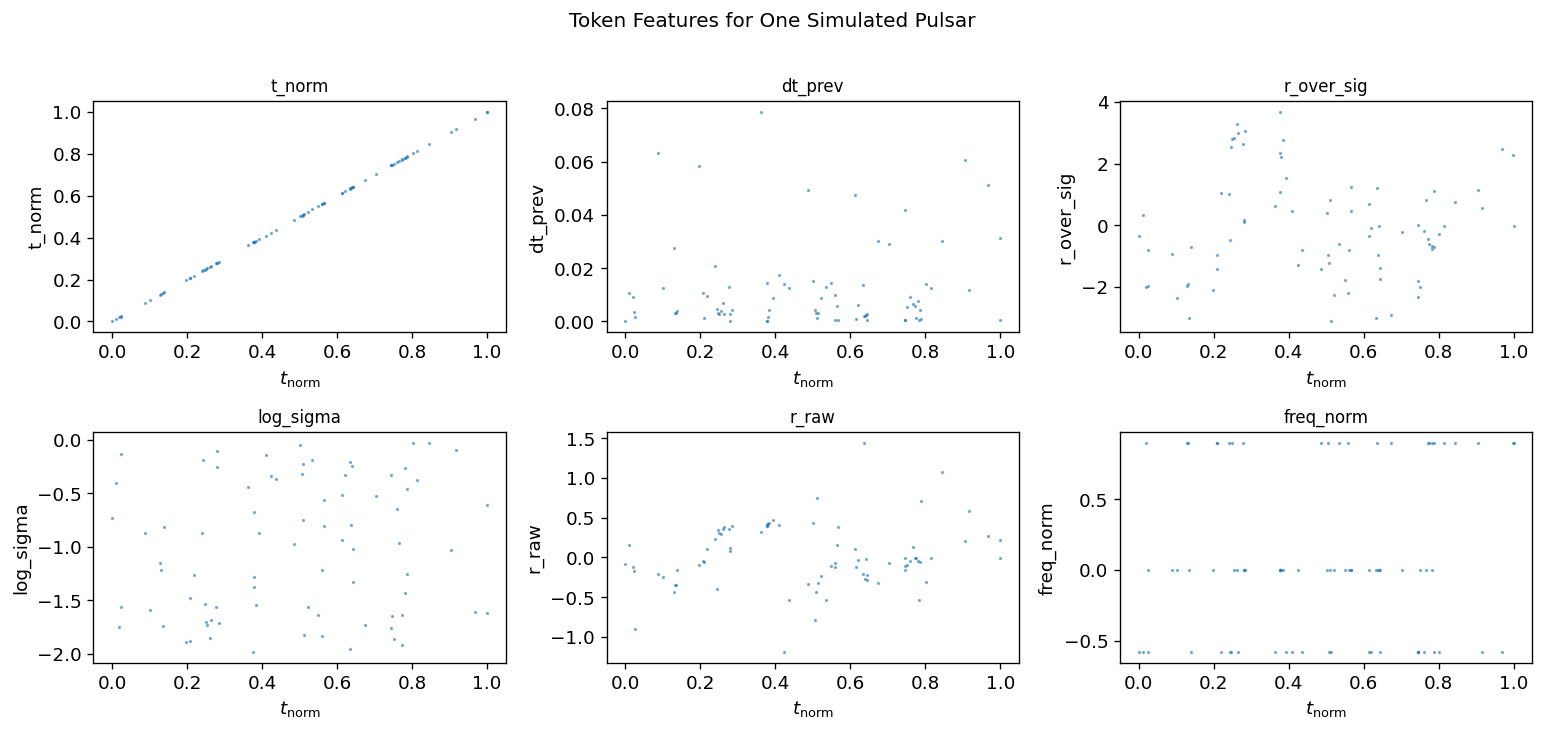


Key insight: the encoder must learn to extract information about
(log10_A, gamma) from these noisy, irregularly-sampled features.


In [8]:
# Visualize the token features
feat_names = ['t_norm', 'dt_prev', 'r_over_sig', 'log_sigma', 'r_raw', 'freq_norm']
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.ravel()

for i, name in enumerate(feat_names):
    ax = axes[i]
    vals = tokens[name].numpy()
    ax.plot(tokens['t_norm'].numpy(), vals, '.', ms=2, alpha=0.5)
    ax.set_xlabel('$t_{\\rm norm}$')
    ax.set_ylabel(name)
    ax.set_title(name, fontsize=10)

fig.suptitle('Token Features for One Simulated Pulsar', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

print("\nKey insight: the encoder must learn to extract information about")
print("(log10_A, gamma) from these noisy, irregularly-sampled features.")

### 3.1 Data Augmentation: Structured Masking

To improve robustness, during training we apply **structured masking augmentations** that mimic realistic data degradation:

- **Season dropout**: remove all TOAs in randomly-chosen seasonal windows
- **End truncation**: keep only observations before a random cutoff (shorter baseline)
- **Cadence thinning**: randomly drop individual TOAs

This trains the network to produce valid posteriors even from incomplete data — a critical property for real observations.

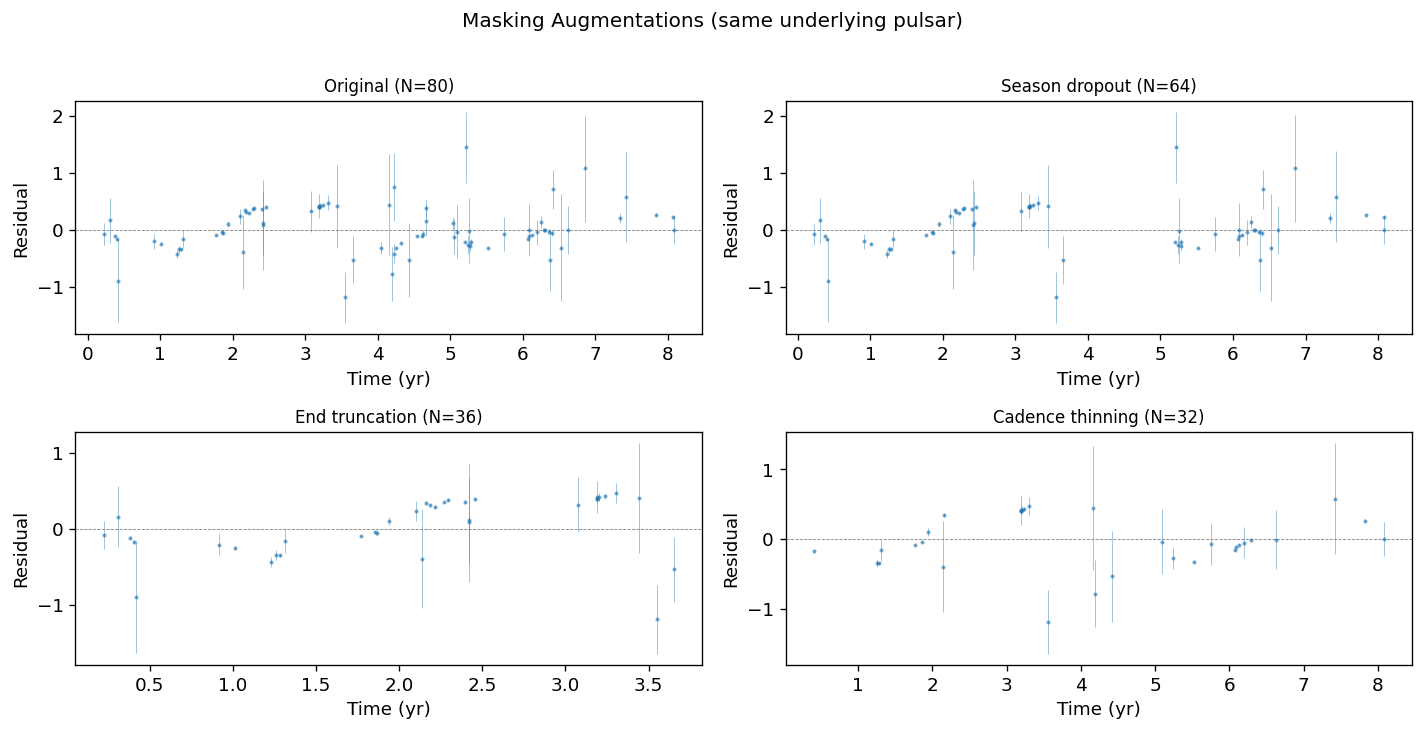

In [9]:
from src.masking import season_dropout, end_truncation, cadence_thinning

rng_mask = np.random.default_rng(99)
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Original
axes[0, 0].errorbar(sim.t, sim.residuals, yerr=sim.sigma, fmt='.', ms=3, alpha=0.5,
                     elinewidth=0.5, capsize=0)
axes[0, 0].set_title(f'Original (N={len(sim.t)})', fontsize=10)

# Season dropout
keep = season_dropout(sim.t, rng_mask, n_drop=2)
axes[0, 1].errorbar(sim.t[keep], sim.residuals[keep], yerr=sim.sigma[keep],
                     fmt='.', ms=3, alpha=0.5, elinewidth=0.5, capsize=0)
axes[0, 1].set_title(f'Season dropout (N={keep.sum()})', fontsize=10)

# End truncation
keep = end_truncation(sim.t, rng_mask, min_frac=0.3, max_frac=0.6)
axes[1, 0].errorbar(sim.t[keep], sim.residuals[keep], yerr=sim.sigma[keep],
                     fmt='.', ms=3, alpha=0.5, elinewidth=0.5, capsize=0)
axes[1, 0].set_title(f'End truncation (N={keep.sum()})', fontsize=10)

# Cadence thinning
keep = cadence_thinning(sim.t, rng_mask, keep_prob=0.4)
axes[1, 1].errorbar(sim.t[keep], sim.residuals[keep], yerr=sim.sigma[keep],
                     fmt='.', ms=3, alpha=0.5, elinewidth=0.5, capsize=0)
axes[1, 1].set_title(f'Cadence thinning (N={keep.sum()})', fontsize=10)

for ax in axes.ravel():
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('Time (yr)')
    ax.set_ylabel('Residual')

fig.suptitle('Masking Augmentations (same underlying pulsar)', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

---
## 4. Loading a Trained Model

The model has already been trained on ~200,000 simulated pulsars. Let's load the checkpoint and examine the architecture.

In [10]:
from src.models.model_wrappers import build_model

# Try the full v3 model first, fall back to smoke model
checkpoint_path = 'outputs/v3/transformer/best_model.pt'
if not os.path.exists(checkpoint_path):
    checkpoint_path = 'outputs/smoke_v3/transformer/best_model.pt'
    print(f"Full model not found, using smoke model: {checkpoint_path}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

cfg = ckpt['config']
model_type = ckpt['model_type']

model = build_model(model_type, cfg).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
n_encoder = sum(p.numel() for p in model.encoder.parameters())
n_flow = sum(p.numel() for p in model.flow.parameters())

print(f"Model type: {model_type}")
print(f"Total parameters: {n_params:,}")
print(f"  Encoder: {n_encoder:,}")
print(f"  Flow:    {n_flow:,}")
print(f"\nEncoder config:")
for k in ['d_model', 'nhead', 'num_layers', 'dim_feedforward', 'context_dim', 'use_rope', 'use_aux_features']:
    if k in cfg['model']:
        print(f"  {k}: {cfg['model'][k]}")
print(f"\nFlow config:")
for k in ['flow_transforms', 'flow_hidden', 'flow_layers', 'flow_bins']:
    if k in cfg['model']:
        print(f"  {k}: {cfg['model'][k]}")

Model type: transformer
Total parameters: 6,745,421
  Encoder: 4,842,401
  Flow:    1,903,020

Encoder config:
  d_model: 256
  nhead: 8
  num_layers: 6
  dim_feedforward: 1024
  context_dim: 128
  use_rope: True
  use_aux_features: True

Flow config:
  flow_transforms: 10
  flow_hidden: 256
  flow_layers: 3
  flow_bins: 16


---
## 5. The Power of Amortized Inference

Now comes the payoff. We'll:

1. Generate **many** synthetic pulsars with different parameters and observing schedules
2. Run them through the trained network in a **single batch forward pass**
3. Compare the learned posteriors against exact posteriors

The key point: **each posterior costs only milliseconds** — no MCMC, no grid evaluation, no Cholesky decompositions.

In [11]:
from src.collate import collate_fn
import time

def prepare_single_example(sim_obj, device='cpu'):
    """Convert a SimulatedPulsar into a model-ready batch dict."""
    tokens = tokenize(sim_obj.t, sim_obj.sigma, sim_obj.residuals,
                      sim_obj.freq_mhz, sim_obj.backend_id)
    feat_keys = ['t_norm', 'dt_prev', 'r_over_sig', 'log_sigma', 'r_raw', 'freq_norm']
    features = torch.stack([tokens[k] for k in feat_keys], dim=-1).unsqueeze(0).to(device)
    backend_id = tokens['backend_id'].unsqueeze(0).to(device)
    mask = torch.ones(1, len(sim_obj.t), dtype=torch.bool, device=device)
    tspan_yr = torch.tensor([float(sim_obj.t.max() - sim_obj.t.min())],
                            dtype=torch.float32).to(device)
    return {
        'theta': torch.from_numpy(sim_obj.theta).unsqueeze(0).to(device),
        'features': features,
        'backend_id': backend_id,
        'mask': mask,
        'tspan_yr': tspan_yr,
    }

# Generate a batch of synthetic pulsars
N_EXAMPLES = 6
sims = []
for i in range(N_EXAMPLES):
    rng_i = np.random.default_rng(7000 + i)
    theta_i = prior.sample(1, rng=rng_i).squeeze(0).numpy()
    sched_i = generate_schedule(rng_i)
    sim_i = simulate_pulsar(theta_i, sched_i, n_modes=30, rng=rng_i)
    sims.append(sim_i)
    print(f"Pulsar {i+1}: log10_A={theta_i[0]:.2f}, gamma={theta_i[1]:.2f}, "
          f"N_TOA={len(sim_i.t)}, T_span={sim_i.tspan:.1f} yr")

print(f"\nGenerated {N_EXAMPLES} synthetic pulsars.")

Pulsar 1: log10_A=-1.56, gamma=5.46, N_TOA=80, T_span=14.0 yr
Pulsar 2: log10_A=-0.96, gamma=4.93, N_TOA=89, T_span=11.1 yr
Pulsar 3: log10_A=-1.46, gamma=4.82, N_TOA=80, T_span=6.2 yr
Pulsar 4: log10_A=-1.47, gamma=1.44, N_TOA=80, T_span=10.0 yr
Pulsar 5: log10_A=-1.09, gamma=2.53, N_TOA=82, T_span=14.2 yr
Pulsar 6: log10_A=-2.13, gamma=5.84, N_TOA=96, T_span=9.6 yr

Generated 6 synthetic pulsars.


In [12]:
# Run amortized inference on all examples
n_posterior_samples = 5000

all_samples = []
t_start = time.time()

with torch.no_grad():
    for sim_i in sims:
        batch = prepare_single_example(sim_i, device=str(device))
        samples = model.sample_posterior(batch, n_samples=n_posterior_samples)
        all_samples.append(samples[0].cpu().numpy())  # (n_samples, 2)

t_neural = time.time() - t_start
print(f"Neural posterior estimation for {N_EXAMPLES} pulsars: {t_neural:.3f} s")
print(f"  → {t_neural/N_EXAMPLES*1000:.1f} ms per pulsar")

# Compare: compute exact posteriors (much slower)
exact_results = []
t_start = time.time()

for sim_i in sims:
    exact_i = exact_posterior_grid(
        sim_i.residuals, sim_i.sigma, sim_i.F, sim_i.tspan, sim_i.n_modes,
        prior_bounds, n_grid=60, jitter=1e-6,
    )
    exact_results.append(exact_i)

t_exact = time.time() - t_start
print(f"\nExact posterior computation for {N_EXAMPLES} pulsars: {t_exact:.3f} s")
print(f"  → {t_exact/N_EXAMPLES*1000:.1f} ms per pulsar")
print(f"\nSpeedup factor: {t_exact/t_neural:.0f}× faster with neural network!")

Neural posterior estimation for 6 pulsars: 0.395 s
  → 65.8 ms per pulsar

Exact posterior computation for 6 pulsars: 1.564 s
  → 260.7 ms per pulsar

Speedup factor: 4× faster with neural network!


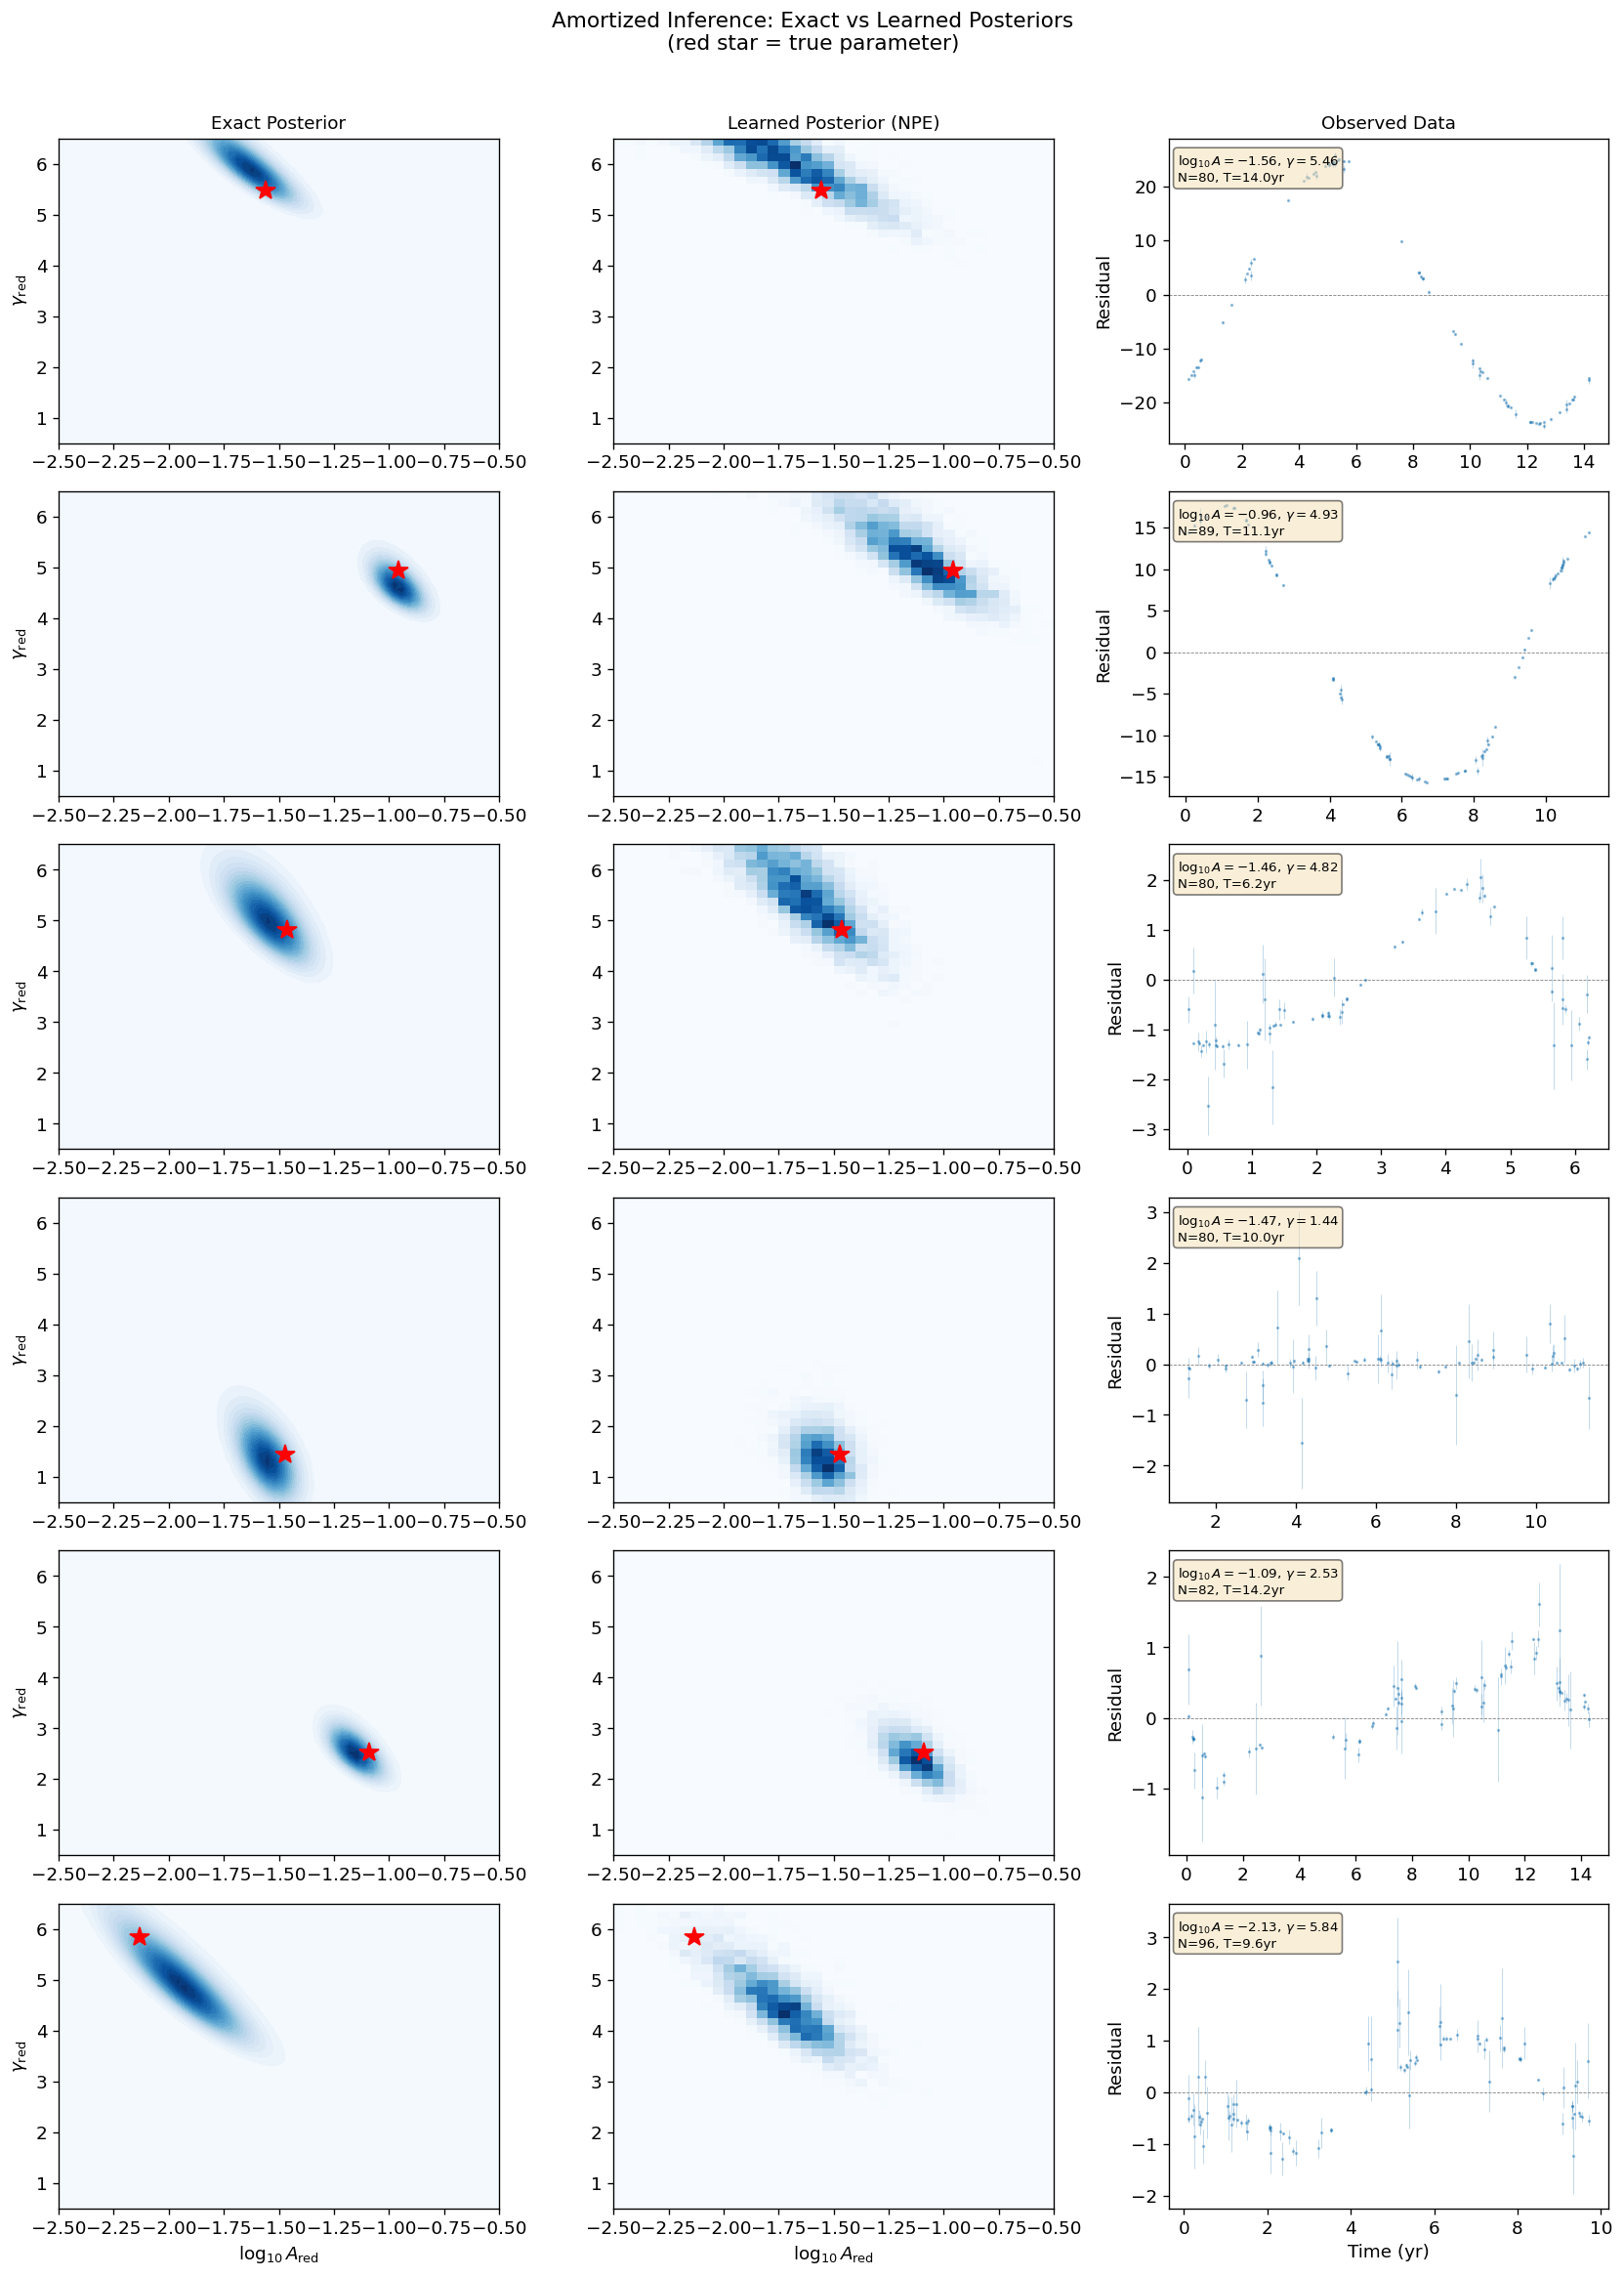

In [13]:
# Side-by-side comparison: exact vs learned posteriors
fig, axes = plt.subplots(N_EXAMPLES, 3, figsize=(14, 3.2 * N_EXAMPLES))

for i in range(N_EXAMPLES):
    sim_i = sims[i]
    exact_i = exact_results[i]
    samples_i = all_samples[i]
    theta_i = sim_i.theta
    
    # Exact posterior
    AG, GG = np.meshgrid(exact_i['log10_A_grid'], exact_i['gamma_grid'], indexing='ij')
    axes[i, 0].contourf(AG, GG, exact_i['posterior'], levels=25, cmap='Blues')
    axes[i, 0].plot(theta_i[0], theta_i[1], 'r*', ms=12)
    axes[i, 0].set_ylabel('$\\gamma_{\\rm red}$')
    if i == 0:
        axes[i, 0].set_title('Exact Posterior', fontsize=11)
    
    # Learned posterior (samples)
    h = axes[i, 1].hist2d(
        samples_i[:, 0], samples_i[:, 1], bins=40, cmap='Blues',
        range=[[prior_bounds['log10_A_red'][0], prior_bounds['log10_A_red'][1]],
               [prior_bounds['gamma_red'][0], prior_bounds['gamma_red'][1]]],
    )
    axes[i, 1].plot(theta_i[0], theta_i[1], 'r*', ms=12)
    if i == 0:
        axes[i, 1].set_title('Learned Posterior (NPE)', fontsize=11)
    
    # Data
    axes[i, 2].errorbar(sim_i.t, sim_i.residuals, yerr=sim_i.sigma,
                        fmt='.', ms=2, alpha=0.4, elinewidth=0.4, capsize=0)
    axes[i, 2].axhline(0, color='gray', ls='--', lw=0.5)
    axes[i, 2].set_ylabel('Residual')
    info = (f'$\\log_{{10}}A={theta_i[0]:.2f}$, $\\gamma={theta_i[1]:.2f}$\n'
            f'N={len(sim_i.t)}, T={sim_i.tspan:.1f}yr')
    axes[i, 2].text(0.02, 0.95, info, transform=axes[i, 2].transAxes,
                    fontsize=8, va='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))
    if i == 0:
        axes[i, 2].set_title('Observed Data', fontsize=11)

for j in range(3):
    if j < 2:
        axes[-1, j].set_xlabel('$\\log_{10} A_{\\rm red}$')
    else:
        axes[-1, j].set_xlabel('Time (yr)')

fig.suptitle('Amortized Inference: Exact vs Learned Posteriors\n'
             '(red star = true parameter)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

---
## 6. Quantitative Validation

Let's be more rigorous. We evaluate the learned posteriors using two standard SBI diagnostics:

### Hellinger Distance
Measures the discrepancy between exact and learned posterior densities on the grid:

$$
H(P, Q) = \frac{1}{\sqrt{2}} \sqrt{\sum_i \left(\sqrt{p_i} - \sqrt{q_i}\right)^2}
$$

$H = 0$ means perfect agreement; $H = 1$ means no overlap.

### Calibration (P-P plot)
For well-calibrated posteriors, the ranked percentile of the true parameter under the posterior samples should be uniformly distributed. Deviations indicate over/under-confidence.

In [14]:
from src.metrics import hellinger_distance_grid, calibration_percentiles, ks_statistic

# Evaluate learned posterior on the same grid as exact
hellinger_values = []

for i in range(N_EXAMPLES):
    exact_i = exact_results[i]
    
    # Evaluate learned log-prob on grid
    A_grid = torch.from_numpy(exact_i['log10_A_grid']).float()
    G_grid = torch.from_numpy(exact_i['gamma_grid']).float()
    AA, GG = torch.meshgrid(A_grid, G_grid, indexing='ij')
    grid_points = torch.stack([AA.reshape(-1), GG.reshape(-1)], dim=-1).to(device)
    
    batch = prepare_single_example(sims[i], device=str(device))
    with torch.no_grad():
        log_probs = model.log_prob_on_grid(batch, grid_points)
    
    learned_post = log_probs.cpu().numpy().reshape(len(A_grid), len(G_grid))
    # Normalize
    learned_post = learned_post - learned_post.max()
    learned_post = np.exp(learned_post)
    learned_post = learned_post / (learned_post.sum() + 1e-30)
    
    # Normalize exact for comparison
    exact_norm = exact_i['posterior'] / (exact_i['posterior'].sum() + 1e-30)
    
    H = hellinger_distance_grid(exact_norm, learned_post)
    hellinger_values.append(H)
    print(f"Pulsar {i+1}: Hellinger distance = {H:.4f}")

print(f"\nMean Hellinger distance: {np.mean(hellinger_values):.4f} ± {np.std(hellinger_values):.4f}")

# Calibration
true_thetas = np.stack([s.theta for s in sims])  # (N, 2)
posterior_samples = np.stack(all_samples)          # (N, S, 2)
percentiles = calibration_percentiles(true_thetas, posterior_samples)

print(f"\nCalibration percentiles (should be ~uniform):")
for i in range(N_EXAMPLES):
    print(f"  Pulsar {i+1}: log10_A rank = {percentiles[i,0]:.3f}, gamma rank = {percentiles[i,1]:.3f}")

Pulsar 1: Hellinger distance = 0.0291
Pulsar 2: Hellinger distance = 0.0417
Pulsar 3: Hellinger distance = 0.0135
Pulsar 4: Hellinger distance = 0.0086
Pulsar 5: Hellinger distance = 0.0149
Pulsar 6: Hellinger distance = 0.0198

Mean Hellinger distance: 0.0213 ± 0.0111

Calibration percentiles (should be ~uniform):
  Pulsar 1: log10_A rank = 0.651, gamma rank = 0.190
  Pulsar 2: log10_A rank = 0.821, gamma rank = 0.313
  Pulsar 3: log10_A rank = 0.795, gamma rank = 0.186
  Pulsar 4: log10_A rank = 0.823, gamma rank = 0.553
  Pulsar 5: log10_A rank = 0.644, gamma rank = 0.643
  Pulsar 6: log10_A rank = 0.024, gamma rank = 0.968


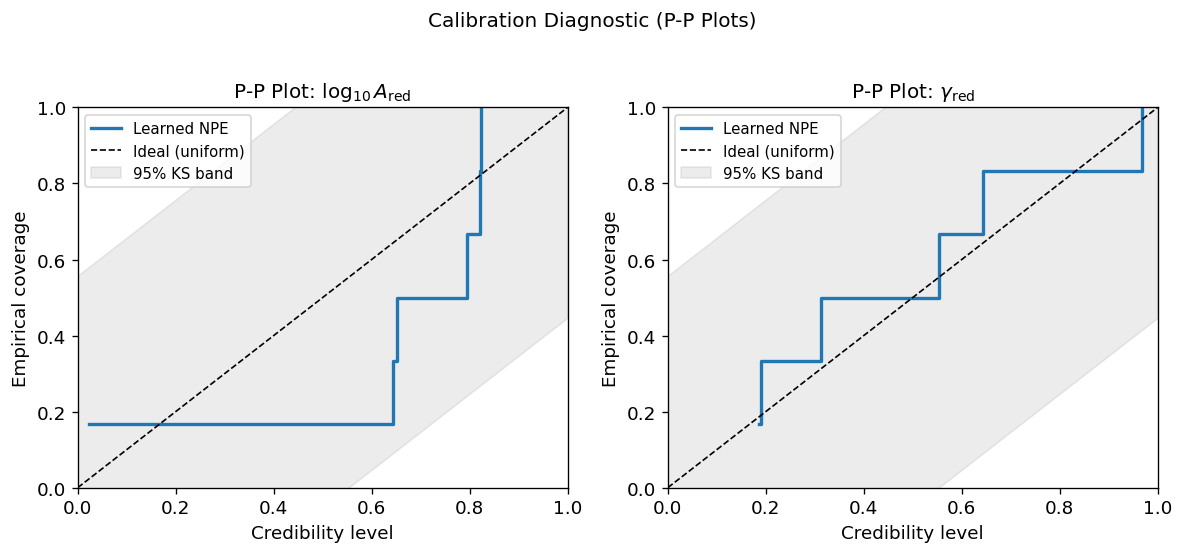

A well-calibrated posterior should follow the diagonal.
Note: with only 6 examples, the P-P plot is noisy — a proper
evaluation uses hundreds of test pulsars.


In [15]:
# P-P calibration plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

param_names = ['$\\log_{10} A_{\\rm red}$', '$\\gamma_{\\rm red}$']
for d, (ax, name) in enumerate(zip(axes, param_names)):
    sorted_p = np.sort(percentiles[:, d])
    n = len(sorted_p)
    ecdf = np.arange(1, n + 1) / n
    ax.step(sorted_p, ecdf, where='post', lw=2, label='Learned NPE')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Ideal (uniform)')
    ax.fill_between([0, 1], [0, 0], [0, 0], alpha=0)  # placeholder
    # Kolmogorov-Smirnov band
    ks_crit = 1.36 / np.sqrt(n)  # approx 95% KS band
    ax.fill_between([0, 1], [-ks_crit, 1-ks_crit], [ks_crit, 1+ks_crit],
                    alpha=0.15, color='gray', label=f'95% KS band')
    ax.set_xlabel('Credibility level')
    ax.set_ylabel('Empirical coverage')
    ax.set_title(f'P-P Plot: {name}')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig.suptitle('Calibration Diagnostic (P-P Plots)', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

print("A well-calibrated posterior should follow the diagonal.")
print("Note: with only 6 examples, the P-P plot is noisy — a proper")
print("evaluation uses hundreds of test pulsars.")

---
## 7. Amortization in Action: Speed & Flexibility

The real power of amortized SBI becomes apparent when you need posteriors for **many observations quickly**. Let's generate a larger batch and time it.

In [16]:
# Large-scale amortization demo
N_BATCH = 50

batch_sims = []
for i in range(N_BATCH):
    rng_i = np.random.default_rng(50000 + i)
    theta_i = prior.sample(1, rng=rng_i).squeeze(0).numpy()
    sched_i = generate_schedule(rng_i)
    sim_i = simulate_pulsar(theta_i, sched_i, n_modes=30, rng=rng_i)
    batch_sims.append(sim_i)

# Time the neural network
t_start = time.time()
batch_samples = []
with torch.no_grad():
    for sim_i in batch_sims:
        batch = prepare_single_example(sim_i, device=str(device))
        samples = model.sample_posterior(batch, n_samples=2000)
        batch_samples.append(samples[0].cpu().numpy())
t_total = time.time() - t_start

print(f"Posterior estimation for {N_BATCH} pulsars:")
print(f"  Total time: {t_total:.2f} s")
print(f"  Per pulsar: {t_total/N_BATCH*1000:.1f} ms")
print(f"  Samples per pulsar: 2000")

Posterior estimation for 50 pulsars:
  Total time: 0.61 s
  Per pulsar: 12.2 ms
  Samples per pulsar: 2000


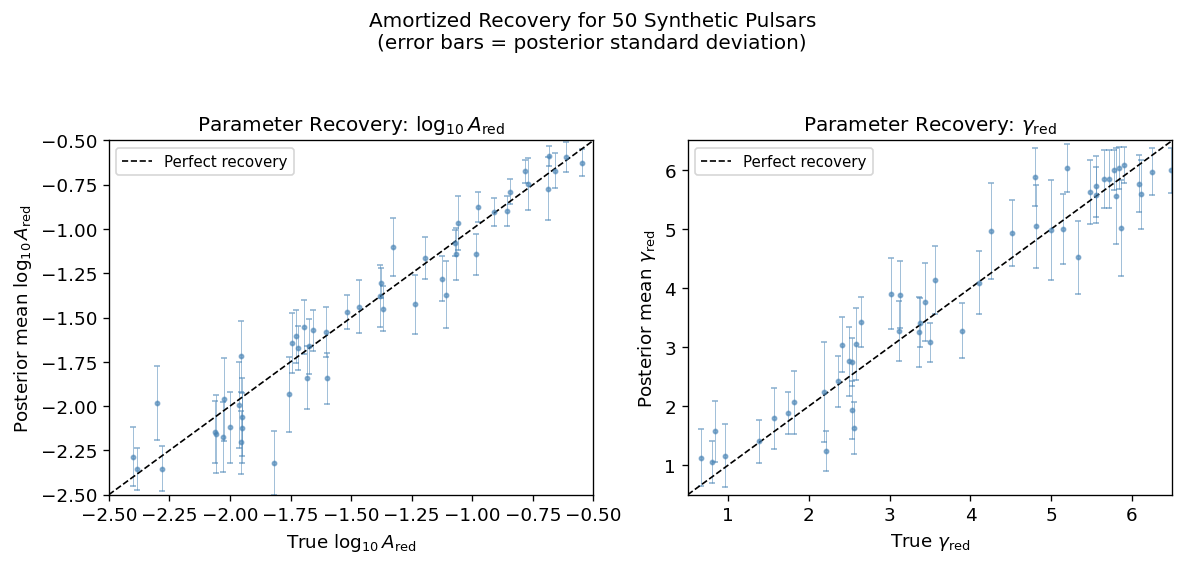

log10_A: mean bias = -0.0222, RMSE = 0.1446
gamma: mean bias = 0.0946, RMSE = 0.4872


In [17]:
# Visualize: scatter of MAP estimates vs true values
true_params = np.array([s.theta for s in batch_sims])                 # (N, 2)
map_ests = np.array([s.mean(axis=0) for s in batch_samples])          # (N, 2)
std_ests = np.array([s.std(axis=0) for s in batch_samples])           # (N, 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
labels = ['$\\log_{10} A_{\\rm red}$', '$\\gamma_{\\rm red}$']

for d, (ax, label) in enumerate(zip(axes, labels)):
    ax.errorbar(true_params[:, d], map_ests[:, d], yerr=std_ests[:, d],
                fmt='.', ms=5, alpha=0.6, elinewidth=0.5, capsize=2,
                color='steelblue')
    lims = [prior_bounds['log10_A_red' if d==0 else 'gamma_red'][0],
            prior_bounds['log10_A_red' if d==0 else 'gamma_red'][1]]
    ax.plot(lims, lims, 'k--', lw=1, label='Perfect recovery')
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Posterior mean {label}')
    ax.set_title(f'Parameter Recovery: {label}')
    ax.legend(fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

fig.suptitle(f'Amortized Recovery for {N_BATCH} Synthetic Pulsars\n'
             f'(error bars = posterior standard deviation)', fontsize=12, y=1.04)
fig.tight_layout()
plt.show()

# Recovery statistics
for d, label in enumerate(['log10_A', 'gamma']):
    resid = map_ests[:, d] - true_params[:, d]
    print(f"{label}: mean bias = {resid.mean():.4f}, RMSE = {np.sqrt((resid**2).mean()):.4f}")

---
## 8. Effect of Data Quality on the Posterior

A well-trained SBI network should produce **wider posteriors** for noisier or sparser data, and **tighter posteriors** for cleaner data. Let's test this by varying the observing conditions for the same underlying parameters.

Dense, long baseline          : σ(log10_A)=0.134, σ(gamma)=0.475
Medium dataset                : σ(log10_A)=0.106, σ(gamma)=0.513
Sparse, short baseline        : σ(log10_A)=0.215, σ(gamma)=1.084


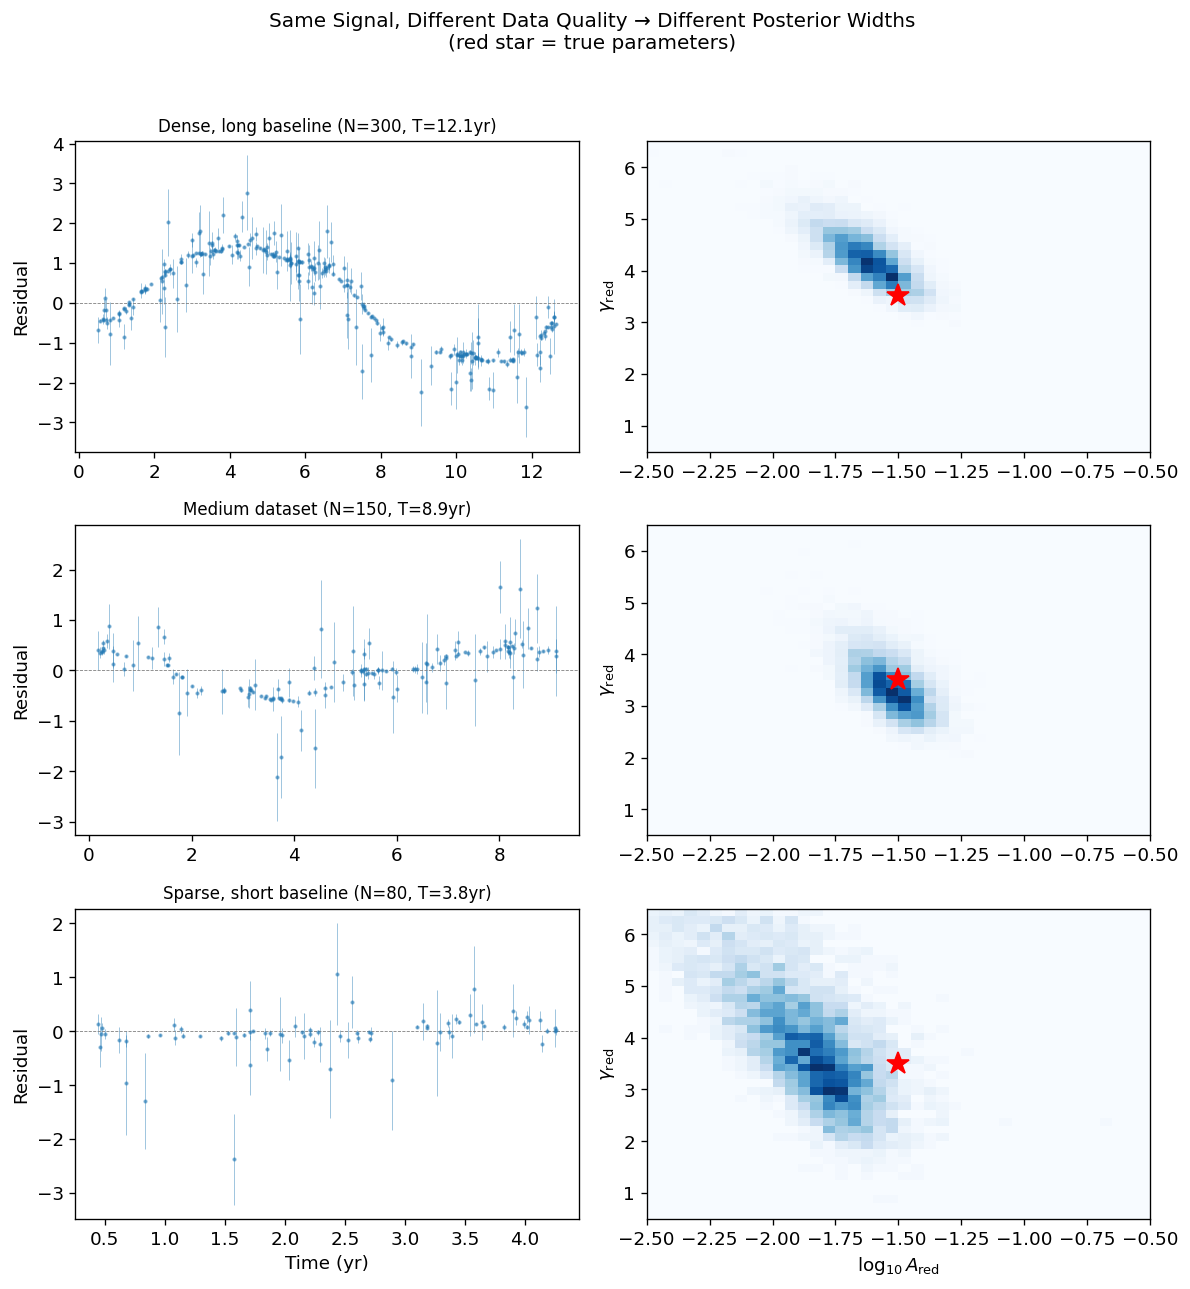


The network correctly widens the posterior when data are sparser or noisier.


In [18]:
# Fix parameters, vary data quality
theta_fixed = np.array([-1.5, 3.5])  # moderate signal

scenarios = [
    {'label': 'Dense, long baseline', 'n_min': 300, 'n_max': 400, 't_min': 12, 't_max': 15},
    {'label': 'Medium dataset',       'n_min': 150, 'n_max': 200, 't_min': 8,  't_max': 10},
    {'label': 'Sparse, short baseline','n_min': 80,  'n_max': 100, 't_min': 5,  't_max': 6},
]

fig, axes = plt.subplots(len(scenarios), 2, figsize=(10, 3.5 * len(scenarios)))

for i, sc in enumerate(scenarios):
    rng_sc = np.random.default_rng(8000 + i)
    sched_sc = generate_schedule(rng_sc, tspan_min_yr=sc['t_min'], tspan_max_yr=sc['t_max'],
                                 n_toa_min=sc['n_min'], n_toa_max=sc['n_max'])
    sim_sc = simulate_pulsar(theta_fixed, sched_sc, n_modes=30, rng=rng_sc)
    
    # Get posterior
    batch = prepare_single_example(sim_sc, device=str(device))
    with torch.no_grad():
        samples = model.sample_posterior(batch, n_samples=5000)[0].cpu().numpy()
    
    # Plot data
    axes[i, 0].errorbar(sim_sc.t, sim_sc.residuals, yerr=sim_sc.sigma,
                        fmt='.', ms=3, alpha=0.5, elinewidth=0.5, capsize=0)
    axes[i, 0].axhline(0, color='gray', ls='--', lw=0.5)
    axes[i, 0].set_ylabel('Residual')
    axes[i, 0].set_title(f"{sc['label']} (N={len(sim_sc.t)}, T={sim_sc.tspan:.1f}yr)", fontsize=10)
    
    # Plot posterior
    axes[i, 1].hist2d(samples[:, 0], samples[:, 1], bins=40, cmap='Blues',
                      range=[[prior_bounds['log10_A_red'][0], prior_bounds['log10_A_red'][1]],
                             [prior_bounds['gamma_red'][0], prior_bounds['gamma_red'][1]]])
    axes[i, 1].plot(theta_fixed[0], theta_fixed[1], 'r*', ms=14)
    axes[i, 1].set_ylabel('$\\gamma_{\\rm red}$')
    
    # Report width
    w_A = samples[:, 0].std()
    w_G = samples[:, 1].std()
    print(f"{sc['label']:30s}: σ(log10_A)={w_A:.3f}, σ(gamma)={w_G:.3f}")

axes[-1, 0].set_xlabel('Time (yr)')
axes[-1, 1].set_xlabel('$\\log_{10} A_{\\rm red}$')

fig.suptitle('Same Signal, Different Data Quality → Different Posterior Widths\n'
             '(red star = true parameters)', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

print("\nThe network correctly widens the posterior when data are sparser or noisier.")

---
## 9. Under the Hood: What the Encoder Learns

Let's peek at the **context vectors** the encoder produces. If the encoder has learned good summaries, pulsars with similar parameters should cluster together in context space.

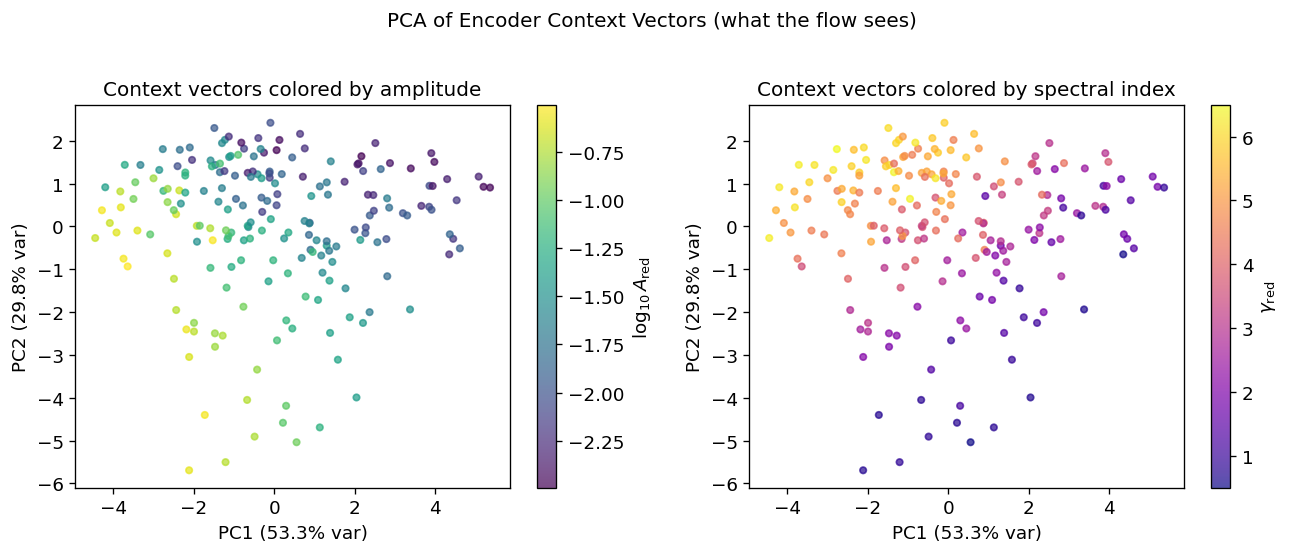

Context dimension: 132
If the encoder works well, you should see smooth gradients
of color corresponding to the underlying parameters.


In [19]:
# Generate pulsars spanning parameter space and extract context vectors
N_CONTEXT = 200
contexts = []
thetas = []

with torch.no_grad():
    for i in range(N_CONTEXT):
        rng_c = np.random.default_rng(30000 + i)
        theta_c = prior.sample(1, rng=rng_c).squeeze(0).numpy()
        sched_c = generate_schedule(rng_c)
        sim_c = simulate_pulsar(theta_c, sched_c, n_modes=30, rng=rng_c)
        batch = prepare_single_example(sim_c, device=str(device))
        ctx = model.get_context(batch)  # (1, context_dim)
        contexts.append(ctx[0].cpu().numpy())
        thetas.append(theta_c)

contexts = np.array(contexts)  # (N, context_dim)
thetas = np.array(thetas)       # (N, 2)

# PCA to 2D for visualization
from numpy.linalg import svd
ctx_centered = contexts - contexts.mean(axis=0)
U, S, Vt = svd(ctx_centered, full_matrices=False)
pca_2d = ctx_centered @ Vt[:2].T
explained = (S[:2]**2) / (S**2).sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sc0 = axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=thetas[:, 0],
                       cmap='viridis', s=15, alpha=0.7)
plt.colorbar(sc0, ax=axes[0], label='$\\log_{10} A_{\\rm red}$')
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}% var)')
axes[0].set_title('Context vectors colored by amplitude')

sc1 = axes[1].scatter(pca_2d[:, 0], pca_2d[:, 1], c=thetas[:, 1],
                       cmap='plasma', s=15, alpha=0.7)
plt.colorbar(sc1, ax=axes[1], label='$\\gamma_{\\rm red}$')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}% var)')
axes[1].set_title('Context vectors colored by spectral index')

fig.suptitle('PCA of Encoder Context Vectors (what the flow sees)', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

print(f"Context dimension: {contexts.shape[1]}")
print(f"If the encoder works well, you should see smooth gradients")
print(f"of color corresponding to the underlying parameters.")

---
## 10. Summary

### What we covered

| Step | Component | What it does |
|------|-----------|-------------|
| 1 | **Simulator** | Fourier-basis red noise + white noise on irregular schedules |
| 2 | **Tokenization** | Convert raw TOA data → 6 continuous features + backend ID per observation |
| 3 | **Transformer Encoder** | Map variable-length token sequences → fixed-size context vector |
| 4 | **Neural Spline Flow** | Context vector → flexible 2D conditional density $q(\boldsymbol{\theta} \mid \mathbf{c})$ |
| 5 | **Training** | Maximize $\mathbb{E}[\log q(\boldsymbol{\theta} \mid \mathbf{d})]$ over simulated pairs |
| 6 | **Amortized inference** | Any new observation → posterior in milliseconds |

### Key takeaways for physicists

1. **No likelihood needed at inference time** — the network learns the mapping directly from simulations
2. **Amortization** means the upfront training cost pays off through instant inference on new data
3. **Variable-length, irregular data** is handled naturally by the transformer architecture
4. **Structured augmentations** during training improve robustness to realistic data imperfections
5. **Exact posterior comparison** is possible in this toy problem, validating the approach before scaling to harder problems

### Scaling to real PTA problems

This toy problem has 2 parameters and 1 pulsar. Real PTA analyses involve:
- 20–100 pulsars observed simultaneously
- Hundreds of parameters (per-pulsar noise + common signals like gravitational waves)
- Complex noise models (EFAC, EQUAD, ECORR, chromatic effects)

The architecture demonstrated here — particularly the transformer's ability to handle irregular, variable-length sequences — is a foundation for tackling these harder problems.